# Operator Dynamics in Random Bricklayer Circuits with Pauli Propagation

The goal of this notebook is to study the time evolution of a local quantum observable using the Pauli propagation framework implemented in `PauliPropagation.jl`.



In [685]:
#using Pkg; Pkg.add("PauliPropagation")
using PauliPropagation

# Validation of Pauli Propagation on Two-Qubit XX Circuits

We focus on a simple and controlled setting in order to validate the method and build intuition before moving to more complex random circuits.

We consider a system of $n$ qubits arranged on a 1D chain. The quantum dynamics is generated by a circuit composed of **two-qubit gates** applied in a **bricklayer pattern**.

In [686]:
nqubits = 2

topology = bricklayertopology(nqubits; periodic=false)

1-element Vector{Tuple{Int64, Int64}}:
 (1, 2)

Each layer consists of nearest-neighbor gates of the form:

$$
U_{ij} = e^{-i \theta X_i X_j}
$$

where $X_i$ is the Pauli X operator acting on qubit $i$, and $\theta$ is a fixed parameter (Trotter step).


This type of circuit corresponds to a Trotterized time evolution under an XX Hamiltonian:

$$
H = \sum_{\langle i,j \rangle} X_i X_j
$$

In [687]:
function simple_trotter_circuit_XX(nqubits::Integer, nlayers::Integer; topology=nothing)
    circuit::Vector{Gate} = []

    if isnothing(topology)
      topology = bricklayertopology(nqubits; periodic=false)
    end

    for _ in 1:nlayers
      rxxlayer!(circuit, topology)
    end
    return circuit
end

simple_trotter_circuit_XX (generic function with 1 method)

---

## Heisenberg picture

Instead of evolving a quantum state, we study the evolution of an observable $O$ in the Heisenberg picture:

$$
O(t) = U^\dagger O U
$$

In this notebook, we choose as initial observable a local Pauli operator:

$$
O = Z_i
$$

In [688]:
i = 1
Z_i = PauliString(nqubits, :Z, i) # I...IZI...I

observable = Z_i

PauliString(nqubits: 2, 1.0 * ZI)

---

## Pauli propagation method

The key idea of Pauli propagation is to express the observable as a sum of Pauli strings:

$$
O = \sum_\alpha c_\alpha P_\alpha
$$

and to propagate each Pauli string through the circuit.

Under conjugation by quantum gates, Pauli strings transform into linear combinations of other Pauli strings. This leads to a growth in the number of terms, which is controlled in practice using:

- truncation of small coefficients
- limitation of the Pauli weight

This method is particularly efficient when the operator remains relatively sparse in the Pauli basis.

Here we want to verify the implementation : we don't apply truncation.

In [689]:
# the truncations
max_weight = typemax(Int)   # no limit          in the documentation they put = 6
min_abs_coeff = 0.0         # no truncations                  """             = 1e-4

0.0

---

## The propagation in our Circuit

In [690]:
nlayers = 150
circuit = simple_trotter_circuit_XX(nqubits, nlayers; topology)

dt = 0.1 # time step
parameters = ones(countparameters(circuit)) * dt # parameters of all evolution gates take the same value

# propagate through the circuit
pauli_sum = propagate(circuit, observable, parameters; max_weight, min_abs_coeff)

PauliSum(nqubits: 2, 2 Pauli terms:
 0.65029 * YX
 -0.75969 * ZI
)

---

## Result

In [691]:
pauli_sum

PauliSum(nqubits: 2, 2 Pauli terms:
 0.65029 * YX
 -0.75969 * ZI
)

If we calculate the same circuit analytically and compare our results, see [validation_twoQubit_XX_circuit.py](https://github.com/TheoHUETQC/Quantum-ManyBody-Sim-Methods/blob/main/heisenberg-picture/pauli-propagation/validation_twoQubit_XX_circuit.py), we obtain the same result, barring a numerical error of $10^{-6}$ with $150$ evolution steps.

---

## Pauli Entropy

For an observable express as a sum of Pauli strings, we define the Pauli Entropy:

$$ S = - \sum_\alpha |c_\alpha|^2 log(|c_\alpha|^2)$$

In [692]:
function pauli_entropy(pauli_sum::PauliSum)
    return sum(((P, c),) -> c != 0 ? -abs(c)^2 * log(abs(c)^2) : 0.0, pauli_sum)
end

pauli_entropy (generic function with 1 method)

---

## Propagation layer by layer

We need to see how a certain quantity behaves as it propagates through the circuit, which the `propagation()` function in the package does not allow us to do, since it only gives us the result.

In [693]:
function propagate_layerbylayer(circuit, observable::PauliString, parameters=nothing; max_weight::Integer, min_abs_coeff::Float64)
  if parameters == nothing # if the circuit is "home made"
    nparameters = observable.nqubits # or size(topology, 1) cause we take a bricklayertopology topology
  else
    nparameters = lenght(parameters) # countparameters(circuit)
  end
  nlayers = size(circuit,1) ÷ nparameters # on pourrait juste mettre nlayers dans parametre

  result = Float64[]
  current = observable

  for i in nlayers:-1:1 # pour propager on a besoin de donner les couches dans le sens inverse /!\
    first_gate_idx = ((i-1)*nparameters)+1; last_gate_idx = (i * nparameters)
    layer_gates = circuit[first_gate_idx:last_gate_idx]

    current = propagate(layer_gates, current, parameters; max_weight, min_abs_coeff)

    push!(result, overlapwithzero(current))
  end

  return current, result
end

propagate_layerbylayer (generic function with 2 methods)

In [694]:
nqubits = 10
i = 1
Z_i = PauliString(nqubits, :Z, i) # I...IZI...I

observable = Z_i

nlayers = 200

circuit = simple_trotter_circuit_XX(nqubits, nlayers; topology)
dt = 0.1 # time step
parameters = ones(countparameters(circuit)) * dt # parameters of all evolution gates take the same value

entropy = Float64[]
for l in 1:nlayers
    subcircuit = simple_trotter_circuit_XX(nqubits, l; topology=topology)
    pauli_sum = propagate(subcircuit, observable, parameters[1:countparameters(subcircuit)];
                          max_weight, min_abs_coeff)
    S = pauli_entropy(pauli_sum)
    push!(entropy, S)
end

println(pauli_sum)

PauliSum(nqubits: 10, 2 Pauli terms:
 0.91295 * YXIIIIIIII
 0.40808 * ZIIIIIIIII
)


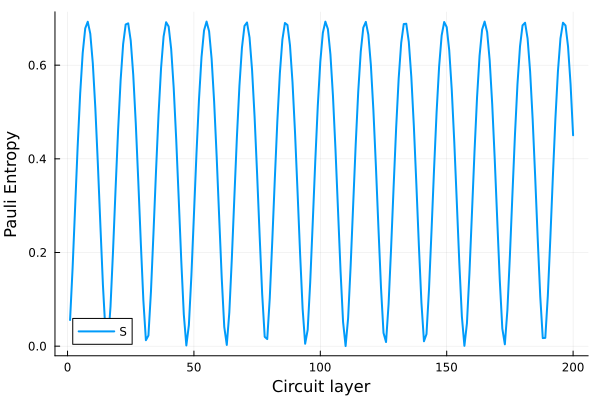

In [695]:
using Plots

plot(1:nlayers, entropy,
     xlabel="Circuit layer",
     ylabel="Pauli Entropy",
     label="S",
     lw=2)

---

# Random Gate Circuit

In a second stage, we will generalize this setup to random circuits of the form:

$$
U = \prod_j e^{i \theta_j P_j}
$$

where:

- $\theta_j$ are random angles
- $P_j$ are random two-qubit Pauli strings


## Decomposition of a 4x4 Unitary Matrix into Pauli Rotations

Let $H$ be an Hermitian matrix $\implies H = H^\dagger$.

Let $k \in \mathbb{R}$ and $U = e^{ikH}$.

$\implies U^\dagger = (e^{ikH})^\dagger = e^{-ikH^\dagger} = e^{-ikH}$
$\implies U U^\dagger = e^{ikH} e^{-ikH} = \mathbb{I} \implies U$ is unitary.


Let $\{P_j\}_{j \in I}$ be the set of Pauli strings for 2 qubits ($|I|=16$).
$\{P_j\}$ forms a basis for the space of $4 \times 4$ Hermitian matrices.

$\implies \forall H, \exists c_j \in \mathbb{R} \text{ such that } H = \sum_{j \in I} c_j P_j$.


Since $P_j$ generally do not commute ($[P_a, P_b] \neq 0$), $e^{i \sum c_j P_j} \neq \prod e^{i c_j P_j}$.

However, as $\{P_j\}$ are generators of the $\mathfrak{u}(4)$ Lie Algebra, by Lie Group theory (Cartan decomposition):

$\forall U \in U(4), \exists \theta_k \in \mathbb{R}, P_k \in \{P_j\}$ such that:

$$U = \prod_{k} e^{i \theta_k P_k}$$

Any $4 \times 4$ unitary matrix $U$ can be decomposed into a finite product of Pauli rotations.


---

Let $P$ a Pauli string and $\theta$ a real number.

$$e^{i\theta P} = \sum_{k=0}^{\infty} \frac{(i\theta P)^{2k}}{(2k)!} + \sum_{k=0}^{\infty} \frac{(i\theta P)^{2k+1}}{(2k+1)!}$$

- $(i\theta P)^{2k} = i^{2k} \theta^{2k} P^{2k} = (-1)^k \theta^{2k} (P^2)^k$. By definition  $P^2 = \mathbb I$, so $P^{2k} = \mathbb I$.
- $(i\theta P)^{2k+1} = i^{2k+1} \theta^{2k+1} P^{2k+1} = i(-1)^k \theta^{2k+1} P$.

$$\implies e^{i\theta P} = \sum_{k=0}^{\infty} \frac{(-1)^k \theta^{2k} \mathbb I}{(2k)!} + \sum_{k=0}^{\infty} \frac{i (-1)^k \theta^{2k+1} P}{(2k+1)!}$$

$$\implies e^{i\theta P} = \mathbb I \left( \sum_{k=0}^{\infty} \frac{(-1)^k \theta^{2k}}{(2k)!} \right) + i P \left( \sum_{k=0}^{\infty} \frac{(-1)^k \theta^{2k+1}}{(2k+1)!} \right)$$

And we know :

- $\cos(\theta) = \sum_{k=0}^{\infty} \frac{(-1)^k \theta^{2k}}{(2k)!}$
- $\sin(\theta) = \sum_{k=0}^{\infty} \frac{(-1)^k \theta^{2k+1}}{(2k+1)!}$

$$\implies e^{i\theta P} = \cos(\theta) \mathbb I + i \sin(\theta) P \qquad \forall P \in \text{Pauli string, } \forall \theta \in \mathbb R$$

---

The final decomposition is:
$$U = \prod_{k} (\cos(\theta_k) \mathbb{I} + i \sin(\theta_k) P_k)$$

In my function `random_unitary_matrix()`, we use the relation :

$$U = e^{i \sum \theta_j P_j}$$
I'll change that later


And we verify if $U$ is unitary with `@assert U * U' ≈ U' * U ≈ I(4)`.


In [696]:
using PauliPropagation: Xmat, Ymat, Zmat
using LinearAlgebra # for I(n)

function random_unitary_matrix()
  pm = [I(2), Xmat, Ymat, Zmat]

  P = I(4)*0 # zero 4x4 matrix
  for Pi in pm
    for Pj in pm
      theta = rand() * 2π # ∈[0, 2π]
      P += kron(Pi, Pj) * theta # P = ∑ θ_j P_j
    end
  end
  U = exp(im * P) # e^{i ∑ θ_j P_j}
  @assert U * U' ≈ U' * U ≈ I(4) # verify U is a 4x4 unitary matrix
  return U
end

function random_block_gate(pair::Tuple{Int64, Int64})
  U = random_unitary_matrix() # need to be 4x4 and unitary
  return TransferMapGate(U, pair)
end

random_block_gate (generic function with 1 method)

<img src="https://github.com/TheoHUETQC/Quantum-ManyBody-Sim-Methods/blob/main/heisenberg-picture/pauli-propagation/figures/brickwork_pattern_circuit.png?raw=1" width="600" alt="Block circuit">

In [697]:
function random_brick_circuit(nqubits::Integer, nlayers::Integer; topology=nothing)
    circuit::Vector{Gate} = []

    if isnothing(topology)
        topology = bricklayertopology(nqubits; periodic=false)
    end

    for _ in 1:nlayers
      # randomm gate on block qubit
      for pair in topology
          push!(circuit, random_block_gate(pair))
      end
    end
    return circuit
end

random_brick_circuit (generic function with 1 method)

Let's apply this circuit on a nq qubits chain :

In [698]:
nq = 6
nlayers = 150

# the truncations
max_weight = 6
min_abs_coeff = 1e-4

topology = bricklayertopology(nq; periodic=true)

# define the circuit as a vector of random block gates
circuit = random_brick_circuit(nq, nlayers; topology)

# Z_i
i=3; Z_i = PauliString(nq, :Z, i) # I...IZI...I

observable = Z_i
println("Observable : ", observable)

Observable : PauliString(nqubits: 6, 1.0 * IIZIII)


## Test

Since the circuit is random, it's more complicated than the previous one, the order of the layers and gates changes everything. Let's check whether the layer-by-layer propagation `propagate_bylayers()` actually allows our observable to propagate through the correct circuit.

In [699]:
#--- layer by layer method
pauli_sum, result = propagate_layerbylayer(circuit, observable; max_weight, min_abs_coeff)
println("Layer by layer method, overlap :", overlapwithzero(pauli_sum))

#--- propagate() method
pauli_sum2 = propagate(circuit, observable; max_weight, min_abs_coeff)
println("propagate method, overlap :", overlapwithzero(pauli_sum2))

println("The two pauli sum are close : ", (pauli_sum ≈ pauli_sum2))

Layer by layer method, overlap :-0.2120031505477209
propagate method, overlap :-0.21200315054772034
The two pauli sum are close : true


We should get the same result since it's the same propagation applied to the same observable.

And now we can plot the evolution of a quantitie in the circuit :

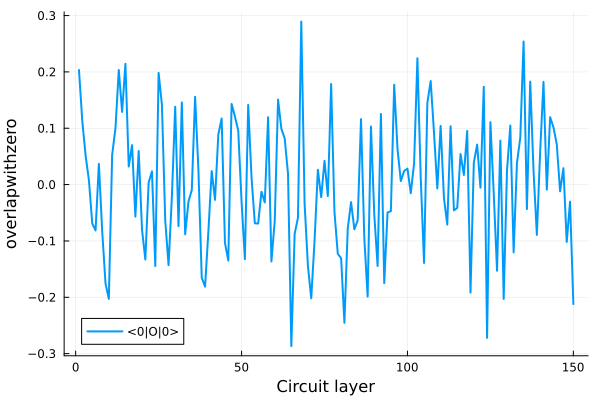

In [700]:
plot(1:nlayers, result,
     xlabel="Circuit layer",
     ylabel="overlapwithzero",
     label="<0|O|0>",
     lw=2)

---

## Evolution

$$\langle A \rangle_{\psi(t)} = \langle \psi(t) | A | \psi(t)\rangle = \langle \psi |\psi \times \psi | U^\dagger A U | \psi\rangle = \langle \psi | \rho_0 U^\dagger A U | \psi\rangle = \langle \psi | \rho_0 U^\dagger A U | \psi\rangle = \langle \psi | U \rho_0 U^\dagger A | \psi\rangle$$

$$\langle A \rangle_{\psi(t)} = Tr(\rho(t)A) = Tr(\rho_0 A(t))$$

---

## References

- https://arxiv.org/abs/2505.21606
- https://github.com/MSRudolph/PauliPropagation.jl
- https://cheatsheet.juliadocs.org/

---

## note

In [701]:
function random_pauli_layer!(circuit, topology)
    for (i, j) in topology
        r = rand()
        if r < 1/3
            append!(circuit, rxxlayer!(Gate[], [(i,j)]))
        elseif r < 2/3
            append!(circuit, ryylayer!(Gate[], [(i,j)]))
        else
            append!(circuit, rzzlayer!(Gate[], [(i,j)]))
        end
    end
end

function random_pauli_layer2!(circuit, topology)
    for (i, j) in topology
        tmp = Gate[]
        r = rand()

        if r < 1/3
            rxxlayer!(tmp, [(i,j)])
        elseif r < 2/3
            ryylayer!(tmp, [(i,j)])
        else
            rzzlayer!(tmp, [(i,j)])
        end

        append!(circuit, tmp)
    end
end

function random_trotter_circuit(nqubits::Integer, nlayers::Integer; topology=nothing)
    circuit::Vector{Gate} = []

    if isnothing(topology)
        topology = bricklayertopology(nqubits; periodic=false)
    end

    for _ in 1:nlayers
        random_pauli_layer!(circuit, topology)
    end

    return circuit
end

# parameters = rand(countparameters(circuit)) .* 2π # random thetas \in [0,2π]

random_trotter_circuit (generic function with 1 method)